In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

# The boundary integral equation (BIE) method 
Reference: Per-Gunnar Martinsson, "Fast direct solvers for elliptic PDEs", SIAM 2019 https://epubs.siam.org/doi/book/10.1137/1.9781611976045

* Chapter 10: theory for the boundary integral equation methods
* Chapter 12: numerics for the BIE methods

The BIE method is tested on a Dirichlet boundary-value problem in a compact star-shaped 2D domain $\Omega$ with a boundary $\Gamma$ parametrized by the polar angle $\phi$ as
$$
G(\phi) = r(\phi)\begin{bmatrix}\cos(\phi)\\\sin(\phi)\end{bmatrix},\quad r(\phi) = r_1 + r_2\cos(m\phi),\quad \phi\in[0,2\pi),
$$
with the exact solution 
$$
u(r,\phi) = 1 + r^3\cos(3\pi).
$$

The boundary function is chosen respectively:
$$
f(\phi) = 1 + (r_1 + r_2\cos(m\phi))^3\cos(3\pi).
$$

To solve this problem, we will need 
$$
\|G'(\phi)\| = \sqrt{[r(\phi)]^2 + [r'(\phi)]^2} = 
\sqrt{(r_1 + r_2\cos(m\phi))^2 + (r_2m\sin(m\phi))^2}.
$$
We also need the unit outer normal to the curve. The tangent vector is given by
$$
G'(t) = r(\phi)\begin{bmatrix}-\sin(\phi)\\\cos(\phi)\end{bmatrix} + r'(\phi)\begin{bmatrix}\cos(\phi)\\\sin(\phi)\end{bmatrix}.
$$
Then the outer unit normal is
$$
n(\phi) = \frac{1}{\|G'(\phi)\|}\left(r(\phi)\begin{bmatrix}\cos(\phi)\\\sin(\phi)\end{bmatrix} + r'(\phi)\begin{bmatrix}\sin(\phi)\\-\cos(\phi)\end{bmatrix}\right).
$$

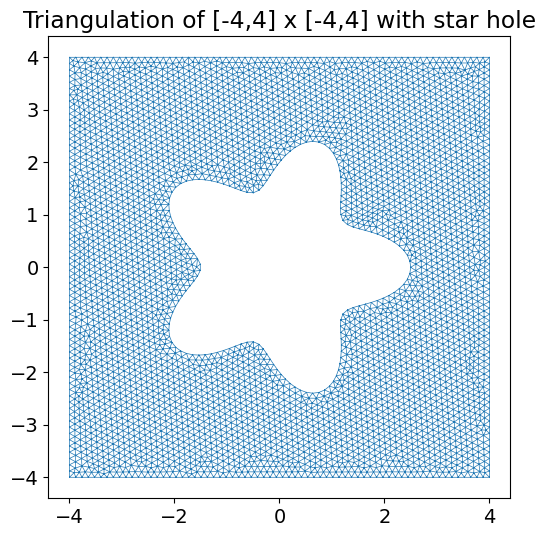

Npts = 4743, Ntri = 8481


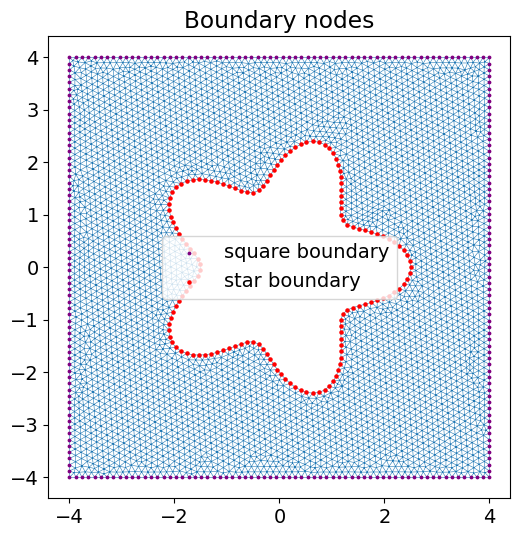

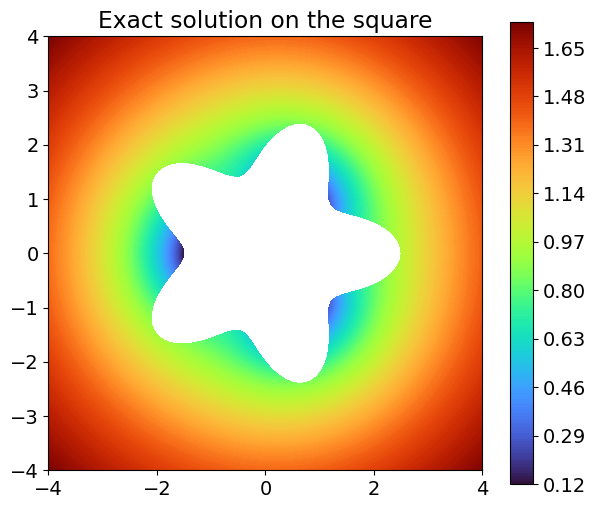

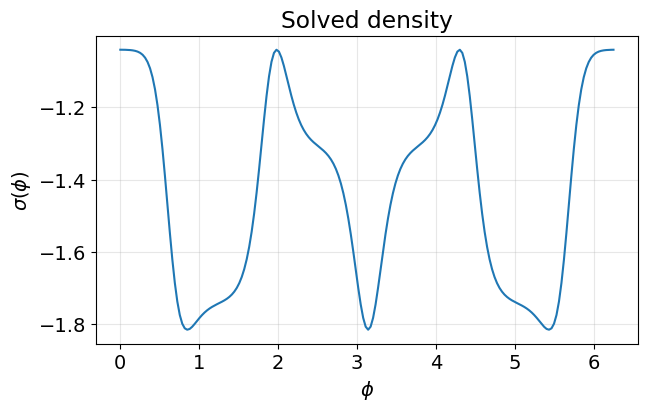

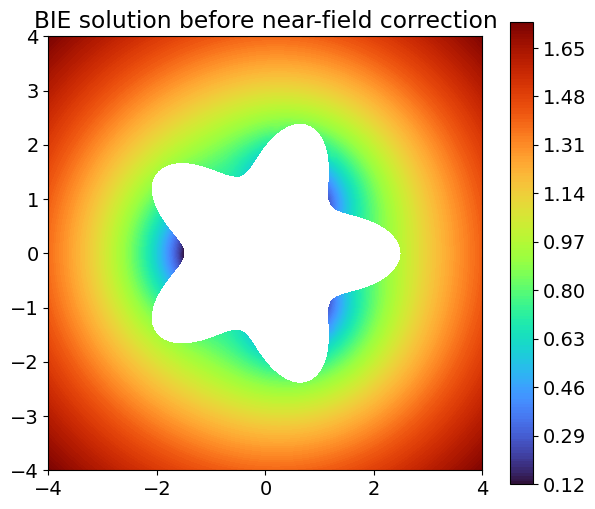

max_error = 9.7928e-01


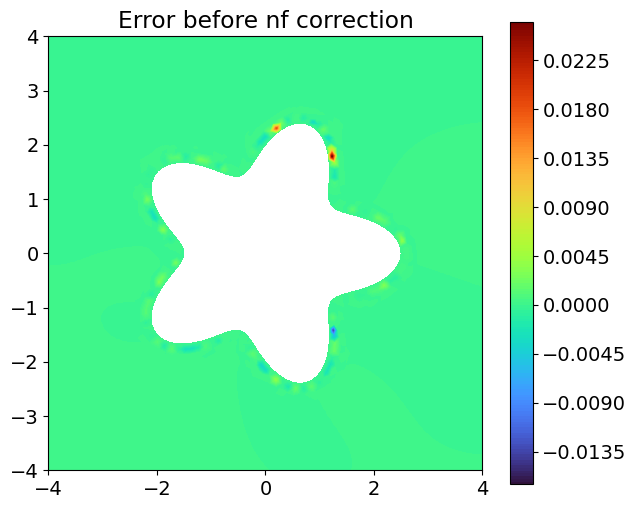

max_error ref = 9.79279e-01


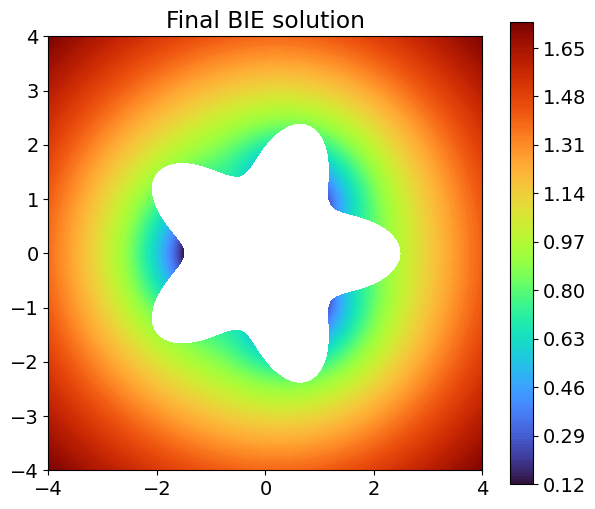

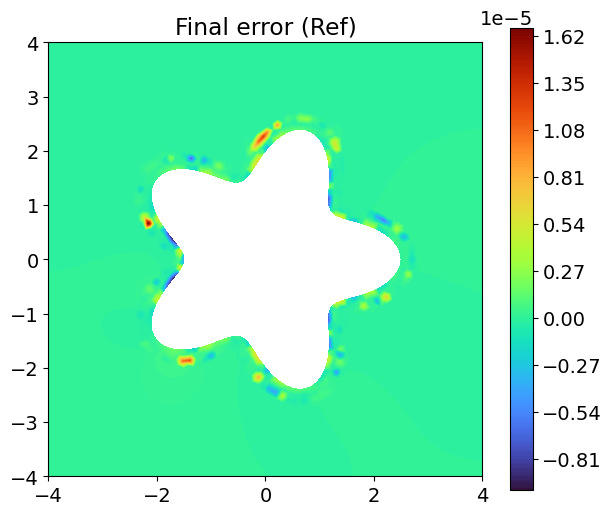

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import pygmsh

plt.rcParams.update({'font.size': 14})



r1 = 2.0
r2 = 0.5
m_star = 5

N = 200          
h_mesh = 0.12     
Lbox = 4.0        
fine_fac = 12     
near_tol = 0.20   



def star_curve_rad(t):
    return r1 + r2*np.cos(m_star*t)

def star_curve_drad(t):
    return -r2*m_star*np.sin(m_star*t)

def star_curve_speed(t):
    r = star_curve_rad(t)
    dr = star_curve_drad(t)
    return np.sqrt(r**2 + dr**2)

def star_curve_normal(t):

    r = star_curve_rad(t)
    dr = star_curve_drad(t)
    speed = np.sqrt(r**2 + dr**2)

    v1 = np.array([np.cos(t), np.sin(t)])
    v2 = np.array([np.sin(t), -np.cos(t)])
    normal = (r*v1 + dr*v2) / speed
    return normal

def get_point(t):
    r = star_curve_rad(t)
    return np.array([r*np.cos(t), r*np.sin(t)])

def get_points(t):
    r = star_curve_rad(t)
    return np.column_stack((r*np.cos(t), r*np.sin(t)))

def get_normals(t):
    normals = np.zeros((len(t), 2))
    for j in range(len(t)):
        normals[j, :] = star_curve_normal(t[j])
    return normals



def exact_sol_cart(x):
    rr = np.linalg.norm(x)
    phi = np.arctan2(x[1], x[0])
    return rr**(-3)*np.cos(3*phi) + np.log(rr)

def bdry_func(t):
    r = star_curve_rad(t)
    return r**(-3)*np.cos(3*t) + np.log(r)


def red_bdry_func(t):
    r = star_curve_rad(t)
    return r**(-3)*np.cos(3*t)

def dl_star(x, y, n_y):

    xy = x - y
    d2 = np.dot(xy, xy)
    return np.dot(xy, n_y) / (2.0*np.pi*d2)


def mesh_square_with_star_hole(h):
    t_vals = np.linspace(0, 2*np.pi, 300, endpoint=False)

    with pygmsh.geo.Geometry() as geom:
    
        p1 = geom.add_point([-Lbox, -Lbox, 0.0], mesh_size=h)
        p2 = geom.add_point([ Lbox, -Lbox, 0.0], mesh_size=h)
        p3 = geom.add_point([ Lbox,  Lbox, 0.0], mesh_size=h)
        p4 = geom.add_point([-Lbox,  Lbox, 0.0], mesh_size=h)
        l1 = geom.add_line(p1, p2)
        l2 = geom.add_line(p2, p3)
        l3 = geom.add_line(p3, p4)
        l4 = geom.add_line(p4, p1)

        outer_loop = geom.add_curve_loop([l1, l2, l3, l4])

        star_pts_cart = [
            [star_curve_rad(t)*np.cos(t), star_curve_rad(t)*np.sin(t), 0.0]
            for t in t_vals
        ]
        star_pts = [geom.add_point(p, mesh_size=h) for p in star_pts_cart]
        star_pts.append(star_pts[0])

        star_curve = geom.add_spline(star_pts)
        inner_loop = geom.add_curve_loop([star_curve])

        geom.add_plane_surface(outer_loop, holes=[inner_loop])

        mesh = geom.generate_mesh()

    tri = mesh.cells_dict["triangle"]
    pts = mesh.points[:, :2]
    return pts, tri

pts, tri = mesh_square_with_star_hole(h_mesh)

plt.figure(figsize=(7,6))
plt.triplot(pts[:,0], pts[:,1], tri, linewidth=0.5)
plt.gca().set_aspect('equal')
plt.title("Triangulation of [-4,4] x [-4,4] with star hole")
plt.show()



Npts = np.size(pts, axis=0)
Ntri = np.size(tri, axis=0)
print(f"Npts = {Npts}, Ntri = {Ntri}")

Nedges = 3*Ntri
edges = np.zeros((Nedges, 2), dtype=int)

for j in range(Ntri):
    T = tri[j, :]
    edges[3*j + 0, :] = np.sort(np.array([T[0], T[1]]))
    edges[3*j + 1, :] = np.sort(np.array([T[0], T[2]]))
    edges[3*j + 2, :] = np.sort(np.array([T[1], T[2]]))

unique_edges, counts = np.unique(edges, axis=0, return_counts=True)
ind = np.argwhere(counts == 1)
Bdry = np.unique(unique_edges[ind, :].ravel())

mesh_pts = np.unique(unique_edges.ravel())

tol = 1e-8
xv = pts[Bdry, 0]
yv = pts[Bdry, 1]

is_outer = (
    (np.abs(xv+Lbox) < tol) |
    (np.abs(xv-Lbox) < tol) |
    (np.abs(yv+Lbox) < tol) |
    (np.abs(yv-Lbox) < tol)
)

OutBdry = Bdry[is_outer]
InnBdry = Bdry[~is_outer]

EvalPts = np.setdiff1d(mesh_pts, InnBdry)

plt.figure(figsize=(6,6))
plt.triplot(pts[:,0], pts[:,1], tri, linewidth=0.4)
plt.scatter(pts[OutBdry,0], pts[OutBdry,1], s=3, c='purple', label='square boundary')
plt.scatter(pts[InnBdry,0], pts[InnBdry,1], s=5, c='red', label='star boundary')
plt.legend()
plt.gca().set_aspect('equal')
plt.title("Boundary nodes")
plt.show()


u_exact = np.zeros((Npts,))
for j in range(Npts):
    u_exact[j] = exact_sol_cart(pts[j, :])

plt.figure(figsize=(7,6))
plt.tricontourf(pts[:,0], pts[:,1], tri, u_exact, levels=200, cmap='turbo')
plt.gca().set_aspect('equal')
plt.colorbar()
plt.title("Exact solution on the square")
plt.show()


p = np.linspace(0, 2*np.pi, N+1)
p = np.delete(p, -1)
h = p[1] - p[0]

Y = np.zeros((N, 2))
N_Y = np.zeros((N, 2))
SPD = np.zeros((N,))

for j in range(N):
    Y[j, :] = get_point(p[j])
    N_Y[j, :] = star_curve_normal(p[j])
    SPD[j] = star_curve_speed(p[j])

g = red_bdry_func(p)


def Dmatrix_ext(p):
    N = np.size(p)
    D = np.zeros((N, N))
    for i in range(N):
        x = get_point(p[i])
        for j in range(N):
            if i != j:
                y = get_point(p[j])
                ny = star_curve_normal(p[j])
                spd = star_curve_speed(p[j])
                D[i, j] = dl_star(x, y, ny) * spd
            else:
                p1 = p[j] + 1e-6
                y1 = get_point(p1)
                p2 = p[j] - 1e-6
                y2 = get_point(p2)

                ny1 = star_curve_normal(p1)
                ny2 = star_curve_normal(p2)

                spd1 = star_curve_speed(p1)
                spd2 = star_curve_speed(p2)

                D1 = dl_star(x, y1, ny1) * spd1
                D2 = dl_star(x, y2, ny2) * spd2
                D[i, j] = 0.5*(D1 + D2)
    return h*D

D = Dmatrix_ext(p)
A = 0.5*np.eye(N) + D
sigma = np.linalg.solve(A, g)

plt.figure(figsize=(7,4))
plt.plot(p, sigma)
plt.xlabel(r'$\phi$')
plt.ylabel(r'$\sigma(\phi)$')
plt.title("Solved density")
plt.grid(True, alpha=0.3)
plt.show()



u = np.zeros((Npts,))
Dvec = np.zeros((N,))

for j in range(len(EvalPts)):
    ind = EvalPts[j]
    x = pts[ind, :]

    for k in range(N):
        y = Y[k, :]
        ny = N_Y[k, :]
        spd = SPD[k]
        Dvec[k] = dl_star(x, y, ny) * spd

    rr = np.linalg.norm(x)
    u[ind] = np.dot(Dvec, sigma) * h + np.log(rr)


for j in range(len(InnBdry)):
    ind = InnBdry[j]
    x = pts[ind, :]
    phi = np.arctan2(x[1], x[0])
    u[ind] = bdry_func(phi)

plt.figure(figsize=(7,6))
plt.tricontourf(pts[:,0], pts[:,1], tri, u, levels=200, cmap='turbo')
plt.gca().set_aspect('equal')
plt.colorbar()
plt.title("BIE solution before near-field correction")
plt.show()

error = u - u_exact
max_error = np.max(np.abs(error))
print(f"max_error = {max_error:.4e}")

plt.figure(figsize=(7,6))
plt.tricontourf(pts[:,0], pts[:,1], tri, error, levels=200, cmap='turbo')
plt.gca().set_aspect('equal')
plt.colorbar()
plt.title("Error before nf correction")
plt.show()



p_aux = np.zeros((N+1,))
sigma_aux = np.zeros((N+1,))
p_aux[:N] = p
p_aux[-1] = 2*np.pi
sigma_aux[:N] = sigma
sigma_aux[-1] = sigma[0]

cs = CubicSpline(p_aux, sigma_aux, bc_type='periodic')

p_fine = np.linspace(0, 2*np.pi, 12*N + 1)
sigma_fine = cs(p_fine)
p_fine = np.delete(p_fine, -1)
sigma_fine = np.delete(sigma_fine, -1)
Nc_fine = np.size(p_fine)
h_fine = 2*np.pi / Nc_fine

Y_fine = np.zeros((Nc_fine, 2))
N_Y_fine = np.zeros((Nc_fine, 2))
SPD_fine = np.zeros((Nc_fine,))

for j in range(Nc_fine):
    Y_fine[j, :] = get_point(p_fine[j])
    N_Y_fine[j, :] = star_curve_normal(p_fine[j])
    SPD_fine[j] = star_curve_speed(p_fine[j])

def dist_to_boundary(x, Yb):
    return np.min(np.linalg.norm(Yb - x[None, :], axis=1))

Dvec_fine = np.zeros((Nc_fine,))

for j in range(len(EvalPts)):
    ind = EvalPts[j]
    x = pts[ind, :]
    d = dist_to_boundary(x, Y)

    if d < near_tol:
        for k in range(Nc_fine):
            y = Y_fine[k, :]
            ny = N_Y_fine[k, :]
            spd = SPD_fine[k]
            Dvec_fine[k] = dl_star(x, y, ny) * spd

        rr = np.linalg.norm(x)
        u[ind] = np.dot(Dvec_fine, sigma_fine) * h_fine + np.log(rr)


for j in range(len(InnBdry)):
    ind = InnBdry[j]
    x = pts[ind, :]
    phi = np.arctan2(x[1], x[0])
    u[ind] = bdry_func(phi)

error = u - u_exact
max_error = np.max(np.abs(error))

print(f"max_error ref = {max_error:.5e}")

plt.figure(figsize=(7,6))
plt.tricontourf(pts[:,0], pts[:,1], tri, u, levels=200, cmap='turbo')
plt.gca().set_aspect('equal')
plt.colorbar()
plt.title("Final BIE solution")
plt.show()

plt.figure(figsize=(7,6))
plt.tricontourf(pts[:,0], pts[:,1], tri, error, levels=200, cmap='turbo')
plt.gca().set_aspect('equal')
plt.colorbar()
plt.title("Final error (Ref)")
plt.show()